# YOLO Solar Event Detection — MLOps Pipeline on GCP
Author: Juan Esteban Agudelo Ortiz

Email: juan.es.agor@gmail.com

---

This notebook builds a production MLOps pipeline around the YOLO11n model
fine-tuned on the LSDO solar dataset. The pipeline covers four stages:

1. **API:** FastAPI serving real-time solar event detection using live SDO
   imagery downloaded via `sunpy`.
2. **Containerization:** Docker packaging the API and model into a portable
   image.
3. **Cloud deployment:** Google Cloud Run serving the containerized API at
   scale.
4. **Model monitoring:** BigQuery logging predictions and Looker Studio
   visualizing confidence score distributions and event counts over time —
   the primary tool for detecting model drift in production.

### Why solar imagery for an MLOps tutorial

The same pipeline used here would power a real observatory monitoring
system — detecting solar events in near real-time, logging detections to
a data warehouse, and alerting operators when model confidence drops
anomalously. Every component demonstrated here maps directly to what
industry ML engineering roles require.

### Prerequisites
- Docker installed locally
- A GCP account with billing enabled
- The fine-tuned LSDO model weights at `../models/sdo_best.pt`

### Limitations
1. The model was trained on a three-day sample with data leakage — detections
   on live SDO imagery are illustrative, not scientifically validated.
2. GCP costs money. Cloud Run has a free tier (2 million requests/month)
   but Artifact Registry and BigQuery storage incur small costs.

> **This notebook runs locally, not on Kaggle.** GCP credentials cannot
> be safely exposed in a Kaggle environment. All cells run on your local
> machine with Docker and `gcloud` installed.

## 0. Install dependencies

### Python dependencies

In [1]:
# Run only if not already installed
# !pip install fastapi uvicorn sunpy python-multipart google-cloud-bigquery
# !pip install ultralytics opencv-python matplotlib numpy pillow requests

### Docker

Docker is required to build and run the container locally before pushing
to GCP. Install it from https://docs.docker.com/get-docker/ and verify:

```bash
docker --version
```

### Google Cloud CLI (`gcloud`)

`gcloud` is required to authenticate with GCP, push the container to
Artifact Registry, and deploy to Cloud Run.

**Linux (Pop!_OS / Ubuntu):**
```bash
curl https://sdk.cloud.google.com | bash
exec -l $SHELL
gcloud init
```

After `gcloud init` you will be prompted to log in with your Google
account and select your GCP project. Verify the installation:

```bash
gcloud --version
```

**Authenticate Docker with GCP Artifact Registry:**
```bash
gcloud auth configure-docker us-central1-docker.pkg.dev
```

This allows Docker to push images to your GCP project's Artifact Registry.

## 1. Imports and configuration

In [2]:
import os
import io
import json
import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import cv2
import requests
from ultralytics import YOLO

import sunpy.map
from sunpy.net import Fido, attrs as a
import astropy.units as u

# Datos de Ciencia color palette
PALETTE = {
    "bg":     "#0D1117",
    "orange": "#E85D24",
    "amber":  "#F5A623",
    "yellow": "#FCDE5A",
    "white":  "#FFFFFF",
    "gray":   "#334155",
}

# Solar event classes
CLASS_MAP = {"AR": 0, "FL": 1, "CH": 2, "SG": 3}
CLASS_COLORS = {
    "AR": "#E85D24",
    "FL": "#FCDE5A",
    "CH": "#38BDF8",
    "SG": "#A78BFA",
}
CLASS_NAMES = list(CLASS_MAP.keys())

# Paths
MODELS_DIR = Path("../models")
OUT_DIR    = Path("outputs")
API_DIR    = Path("api")
OUT_DIR.mkdir(exist_ok=True)
API_DIR.mkdir(exist_ok=True)

MODEL_PATH  = MODELS_DIR / "sdo_best.pt"
CONF_THRESH = 0.25
IOU_THRESH  = 0.45

# GCP configuration
GCP_PROJECT    = "datos-de-ciencia"
GCP_REGION     = "us-central1"
GCP_REPO       = "datos-de-ciencia"
IMAGE_NAME     = "yolo-solar-api"
IMAGE_TAG      = "latest"
ARTIFACT_IMAGE = f"{GCP_REGION}-docker.pkg.dev/{GCP_PROJECT}/{GCP_REPO}/{IMAGE_NAME}:{IMAGE_TAG}"
SERVICE_NAME   = "yolo-solar-api"
BQ_DATASET     = "solar_detections"
BQ_TABLE       = "predictions"

print(f"Model path  : {MODEL_PATH}")
print(f"Model exists: {MODEL_PATH.exists()}")
print(f"GCP project : {GCP_PROJECT}")
print(f"Artifact    : {ARTIFACT_IMAGE}")
print("Configuration ready ✓")

Model path  : ../models/sdo_best.pt
Model exists: True
GCP project : datos-de-ciencia
Artifact    : us-central1-docker.pkg.dev/datos-de-ciencia/datos-de-ciencia/yolo-solar-api:latest
Configuration ready ✓


## 2. Load fine-tuned model

We load the YOLO11n model fine-tuned on the LSDO solar dataset. This is
the model that will be served by the API. If the weights are not yet
available locally, download them from the Kaggle notebook output before
running this cell.

In [3]:
model = YOLO(str(MODEL_PATH))
print(f"Model loaded: {MODEL_PATH}")
print(f"Classes     : {model.names}")
print(f"Parameters  : {sum(p.numel() for p in model.model.parameters()):,}")

Model loaded: ../models/sdo_best.pt
Classes     : {0: 'AR', 1: 'FL', 2: 'CH', 3: 'SG'}
Parameters  : 2,590,620


## 3. FastAPI — API structure

The full API code lives at `api/app/`. The structure follows the
standard pattern used in production ML systems: routers define HTTP
endpoints, services contain business logic, and schemas validate
inputs and outputs.
```
api/
├── app/
│   ├── main.py          ← FastAPI app instance and router registration
│   ├── config.py        ← configuration variables
│   ├── routers/
│   │   ├── predict.py   ← /predict and /predict/realtime endpoints
│   │   └── health.py    ← /health endpoint
│   ├── services/
│   │   ├── inference.py ← YOLO inference logic
│   │   └── sdo.py       ← SDO image download via sunpy Fido
│   ├── models/
│   │   └── schemas.py   ← Pydantic request/response schemas
│   └── logging/
│       └── bigquery.py  ← BigQuery prediction logging
├── Dockerfile
└── requirements.txt
```
### `main.py` — application entry point

Creates the FastAPI app instance and registers all routers. This is
the file that `uvicorn` runs. Nothing else lives here — keeping it
minimal is standard practice because it makes testing and dependency
injection cleaner.

### `config.py` — configuration

Centralizes all configuration variables (model path, thresholds,
GCP project, BigQuery dataset). In production this would read from
environment variables so that the same Docker image can be deployed
to different environments (staging, production) without rebuilding.

### `routers/predict.py` — prediction endpoints

Defines two endpoints:

- `POST /predict`: receives an image file as `multipart/form-data`,
  passes it to the inference service, logs the result, and returns
  a JSON response. The separation between the router and the
  inference service means you can swap the model without touching
  the endpoint definition.

- `GET /predict/realtime`: takes a `wavelength` query parameter
  (default: 193Å), calls the SDO service to download the most
  recent AIA image via `sunpy.net.Fido`, runs inference, and
  returns detections. This endpoint is stateless — every call
  fetches fresh data from the VSO archive.

### `routers/health.py` — health check

A single `GET /health` endpoint that returns `{"status": "ok"}`.
Cloud Run uses this to verify that the container started correctly
before routing traffic to it. Without a health check, a failed
startup goes undetected.

### `services/inference.py` — YOLO inference

Contains `run_inference(img_rgb: np.ndarray) -> list[dict]`. This
function is the only place in the codebase that knows about YOLO.
Isolating inference logic here means you can replace YOLO with any
other model by changing one file.

### `services/sdo.py` — SDO image download

Contains `fetch_latest_sdo(wavelength: int) -> np.ndarray`. Queries
the VSO archive via `sunpy.net.Fido`, downloads the most recent
AIA image at the requested wavelength, converts it from FITS/JP2
to an RGB numpy array, and returns it. Keeping this in a service
rather than in the router makes it independently testable.

### `models/schemas.py` — Pydantic schemas

Defines `DetectionResult` and `PredictionResponse` as Pydantic
models. FastAPI uses these to validate response structure and
auto-generate the Swagger documentation at `/docs`. In production,
strict schema validation prevents malformed responses from reaching
downstream consumers.

### `logging/bigquery.py` — prediction logging

Contains `log_prediction(source: str, detections: list)`. Appends
each prediction as a row to a BigQuery table with fields:
`timestamp`, `source`, `n_detections`, `mean_confidence`, and
`detections` as a JSON array. This is the data source for model
monitoring — see Section 7.

## 4. Test the API locally

Before containerizing, we run the API locally to catch runtime errors,
dependency issues, or bugs in the inference logic — shift-left testing.

**Step 1:** Start the server in a separate terminal:

```bash
cd code/4-Yolo_SDO_MLOps/api
uvicorn app.main:app --reload --host 0.0.0.0 --port 8000
```

The `--reload` flag restarts the server automatically when you edit the
code. Never use it in production — it adds overhead and is a security risk.

Once running, the auto-generated Swagger documentation is available at:

```
http://localhost:8000/docs
```

FastAPI generates this from your endpoint definitions and type annotations
automatically — no extra work required. This is one of the main reasons
FastAPI is preferred over Flask in ML engineering roles.

**Step 2:** Run the cells below to test each endpoint.

In [4]:
import requests

BASE_URL = "http://localhost:8000"

# ── Test /health ───────────────────────────────────────────────────────
r = requests.get(f"{BASE_URL}/health")
print(f"Status  : {r.status_code}")
print(f"Response: {r.json()}")
assert r.status_code == 200, "Health check failed"
print("Health check passed ✓")

ConnectionError: HTTPConnectionPool(host='localhost', port=8000): Max retries exceeded with url: /health (Caused by NewConnectionError("HTTPConnection(host='localhost', port=8000): Failed to establish a new connection: [Errno 111] Connection refused"))

In [ ]:
# ── Test /predict with a local SDO image ──────────────────────────────
import sunpy.map
from sunpy.net import Fido, attrs as a
import astropy.units as u
import datetime
from pathlib import Path

# Search window — 48 hours to account for VSO indexing delay
end   = datetime.datetime.utcnow()
start = end - datetime.timedelta(hours=48)

result = Fido.search(
    a.Time(start.strftime("%Y-%m-%dT%H:%M:%S"),
           end.strftime("%Y-%m-%dT%H:%M:%S")),
    a.Instrument("AIA"),
    a.Wavelength(193 * u.angstrom),
)

print(f"Images found: {len(result[0])}")

if len(result) == 0 or len(result[0]) == 0:
    print("No images found — try extending the search window further")
else:
    Path("outputs/test_images").mkdir(parents=True, exist_ok=True)
    downloaded = Fido.fetch(result[0, -1], path="outputs/test_images/")
    test_image = Path(downloaded[0])
    print(f"Downloaded  : {test_image.name}")
    print(f"Size        : {test_image.stat().st_size / 1e6:.1f} MB")


# Convert FITS to PNG for /predict endpoint test
fits_path = next(Path("outputs/test_images").glob("*.fits"))
sdo_map   = sunpy.map.Map(str(fits_path))

img_data  = sdo_map.data.astype(np.float32)
img_norm  = cv2.normalize(img_data, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
img_rgb   = cv2.cvtColor(img_norm, cv2.COLOR_GRAY2RGB)

test_png  = Path("outputs/test_images/test_sdo.png")
cv2.imwrite(str(test_png), cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
print(f"Test image saved: {test_png}")

# Now test /predict
with open(test_png, "rb") as f:
    r = requests.post(
        f"{BASE_URL}/predict",
        files={"file": (test_png.name, f, "image/png")},
    )

print(f"Status  : {r.status_code}")
print(f"Response: {r.json()}")
assert r.status_code == 200, "Predict endpoint failed"
print("Predict endpoint passed ✓")

/tmp/ipykernel_12974/2390735429.py:9: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  end   = datetime.datetime.utcnow()


Images found: 955


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

AIA20260528_173600_0193.fits:   0%|          | 0.00/1.21M [00:00<?, ?B/s]

Downloaded  : AIA20260528_173600_0193.fits
Size        : 1.2 MB
Test image saved: outputs/test_images/test_sdo.png
Status  : 200
Response: {'timestamp': '2026-05-28T17:52:50.678541', 'source': 'test_sdo.png', 'n_detections': 0, 'detections': [], 'mean_confidence': None}
Predict endpoint passed ✓


In [ ]:
# ── Test /predict/realtime ─────────────────────────────────────────────
r = requests.get(
    f"{BASE_URL}/predict/realtime",
    params={"wavelength": 193},
)
print(f"Status  : {r.status_code}")
print(f"Response: {r.json()}")
assert r.status_code == 200, "Realtime endpoint failed"
print("Realtime endpoint passed ✓")

Status  : 200
Response: {'timestamp': '2026-05-28T17:52:59.130197', 'source': 'SDO_AIA_193_2026-05-28T17:36:04', 'n_detections': 0, 'detections': [], 'mean_confidence': None}
Realtime endpoint passed ✓


In [ ]:
# ── Verify prediction log ──────────────────────────────────────────────
import json

log_path = Path("api/logs/predictions.jsonl")
print(f"Log exists: {log_path.exists()}")

if log_path.exists():
    with open(log_path) as f:
        lines = f.readlines()
    print(f"Entries   : {len(lines)}")
    last = json.loads(lines[-1])
    print(f"Last entry:")
    print(f"  source         : {last['source']}")
    print(f"  timestamp      : {last['timestamp']}")
    print(f"  n_detections   : {last['n_detections']}")
    print(f"  mean_confidence: {last['mean_confidence']}")

Log exists: True
Entries   : 5
Last entry:
  source         : SDO_AIA_193_2026-05-28T17:36:04
  timestamp      : 2026-05-28T17:52:59.130197
  n_detections   : 0
  mean_confidence: None


## 5. Docker — containerize the API

We build a Docker image from the `api/` directory and run it locally to verify that the containerized API behaves identically to the local version. This is the last validation step before pushing to GCP.

The Dockerfile is at `api/Dockerfile`. Review it before building — every instruction creates a layer that Docker caches, so understanding the order matters for build performance.

In [ ]:
import subprocess

def run_cmd(cmd: str, check: bool = True) -> str:
    """Run a shell command and print output in real time."""
    print(f"$ {cmd}\n")
    result = subprocess.run(
        cmd, shell=True, text=True,
        capture_output=False,
    )
    if check and result.returncode != 0:
        raise RuntimeError(f"Command failed: {cmd}")
    return result

# ── Build the Docker image ─────────────────────────────────────────────
run_cmd(f"docker build -t {IMAGE_NAME}:{IMAGE_TAG} api/")

$ docker build -t yolo-solar-api:latest api/



#0 building with "default" instance using docker driver

#1 [internal] load build definition from Dockerfile
#1 transferring dockerfile: 1.47kB done
#1 DONE 0.0s

#2 [internal] load metadata for docker.io/library/python:3.12-slim
#2 DONE 0.2s

#3 [internal] load .dockerignore
#3 transferring context: 34B 0.0s done
#3 DONE 0.0s

#4 [internal] load build context
#4 transferring context: 5.69kB 0.0s done
#4 DONE 0.0s

#5 [1/7] FROM docker.io/library/python:3.12-slim@sha256:090ba77e2958f6af52a5341f788b50b032dd4ca28377d2893dcf1ecbdfdfe203
#5 resolve docker.io/library/python:3.12-slim@sha256:090ba77e2958f6af52a5341f788b50b032dd4ca28377d2893dcf1ecbdfdfe203 0.0s done
#5 DONE 0.0s

#6 [3/7] WORKDIR /app
#6 CACHED

#7 [4/7] COPY requirements.txt .
#7 CACHED

#8 [2/7] RUN apt-get update && apt-get install -y     libgl1     libglib2.0-0     libgomp1     && rm -rf /var/lib/apt/lists/*
#8 CACHED

#9 [5/7] RUN pip install --no-cache-dir -r requirements.txt
#9 CACHED

#10 [6/7] COPY app/ ./app/
#10 CA

CompletedProcess(args='docker build -t yolo-solar-api:latest api/', returncode=0)

In [ ]:
# ── Verify the image was created ──────────────────────────────────────
run_cmd(f"docker images {IMAGE_NAME}")

$ docker images yolo-solar-api

IMAGE                   ID             DISK USAGE   CONTENT SIZE   EXTRA
yolo-solar-api:latest   229a20f81527       9.82GB         3.28GB        


CompletedProcess(args='docker images yolo-solar-api', returncode=0)

Once the image is built, run it locally to verify it works inside the container. The `-p 8001:8000` maps port 8001 on your host to port 8000 inside the container — we use a different host port to avoid conflicts with the uvicorn server still running from Section 4.

Open a new terminal and run:

```bash
docker run -p 8001:8000 yolo-solar-api:latest
```

Then run the cells below to test the containerized API.

In [ ]:
# ── Test containerized API ─────────────────────────────────────────────
# Note: container runs on port 8001 to avoid conflict with local server
CONTAINER_URL = "http://localhost:8001"

r = requests.get(f"{CONTAINER_URL}/health")
print(f"Status  : {r.status_code}")
print(f"Response: {r.json()}")
assert r.status_code == 200, "Container health check failed"
print("Container health check passed ✓")

Status  : 200
Response: {'status': 'ok', 'model': 'sdo_best.pt'}
Container health check passed ✓


In [ ]:
# ── Test /predict on containerized API ────────────────────────────────
with open(test_png, "rb") as f:
    r = requests.post(
        f"{CONTAINER_URL}/predict",
        files={"file": (test_png.name, f, "image/png")},
    )

print(f"Status  : {r.status_code}")
print(f"Response: {r.json()}")
assert r.status_code == 200, "Container predict failed"
print("Container predict passed ✓")

Status  : 200
Response: {'timestamp': '2026-05-28T17:53:01.990199', 'source': 'test_sdo.png', 'n_detections': 0, 'detections': [], 'mean_confidence': None}
Container predict passed ✓


If both cells return `200`, the containerized API is identical in behavior to the local version. Stop the container with `CTRL+C` in the terminal where it is running before proceeding to Section 6.

## 6. GCP — deploy to Cloud Run

This section covers four steps:
1. Create the BigQuery dataset and table
2. Create a Service Account with minimum necessary permissions
3. Push the Docker image to Artifact Registry
4. Deploy to Cloud Run with the Service Account assigned

### Why this order matters

The BigQuery table must exist before the API starts logging predictions.
The Service Account must exist before the deployment so Cloud Run can
assign it. The image must be in Artifact Registry before Cloud Run can
pull it.

In [ ]:
# ── Step 1: Create Artifact Registry repository and BigQuery resources ─

# Create Artifact Registry repository
run_cmd(f"""
gcloud artifacts repositories create {GCP_REPO} \
    --repository-format=docker \
    --location={GCP_REGION} \
    --project={GCP_PROJECT} \
    --description="Datos de Ciencia Docker images"
""", check=False)  # check=False because it fails if already exists

# Verify repository exists
run_cmd(f"""
gcloud artifacts repositories describe {GCP_REPO} \
    --location={GCP_REGION} \
    --project={GCP_PROJECT}
""")

# Create BigQuery dataset
run_cmd(f"""
bq mk --dataset \
    --location=US \
    {GCP_PROJECT}:{BQ_DATASET}
""", check=False)  # check=False because it fails if already exists

# Create BigQuery table
run_cmd(f"""
bq mk --table \
    {GCP_PROJECT}:{BQ_DATASET}.{BQ_TABLE} \
    timestamp:STRING,source:STRING,n_detections:INTEGER,mean_confidence:FLOAT,detections:STRING
""", check=False)  # check=False because it fails if already exists

print(f"Artifact Registry repository: {GCP_REPO} ✓")
print(f"BigQuery table: {GCP_PROJECT}.{BQ_DATASET}.{BQ_TABLE} ✓")

$ 
gcloud artifacts repositories create datos-de-ciencia     --repository-format=docker     --location=us-central1     --project=datos-de-ciencia     --description="Datos de Ciencia Docker images"




ERROR: (gcloud.artifacts.repositories.create) ALREADY_EXISTS: the repository already exists


$ 
gcloud artifacts repositories describe datos-de-ciencia     --location=us-central1     --project=datos-de-ciencia




Encryption: Google-managed key
Repository Size: 3277.824MB


createTime: '2026-05-28T20:14:16.279105Z'
description: Datos de Ciencia Docker images
format: DOCKER
mode: STANDARD_REPOSITORY
name: projects/datos-de-ciencia/locations/us-central1/repositories/datos-de-ciencia
registryUri: us-central1-docker.pkg.dev/datos-de-ciencia/datos-de-ciencia
satisfiesPzi: true
updateTime: '2026-05-28T20:17:56.303729Z'
vulnerabilityScanningConfig:
  enablementState: SCANNING_DISABLED
  enablementStateReason: API containerscanning.googleapis.com is not enabled.
  lastEnableTime: '2026-05-28T20:13:56.029541382Z'
$ 
bq mk --dataset     --location=US     datos-de-ciencia:solar_detections


BigQuery error in mk operation: Dataset 'datos-de-ciencia:solar_detections'
already exists.
$ 
bq mk --table     datos-de-ciencia:solar_detections.predictions     timestamp:STRING,source:STRING,n_detections:INTEGER,mean_confidence:FLOAT,detections:STRING


BigQuery error in mk operation: Table 'datos-de-
ciencia:solar_detections.predictions' could not be created; a table with thi

The table schema maps directly to the fields in `log_prediction`:

| Field | Type | Description |
|---|---|---|
| `timestamp` | STRING | UTC time of prediction |
| `source` | STRING | Image filename or SDO identifier |
| `n_detections` | INTEGER | Number of detections in the image |
| `mean_confidence` | FLOAT | Average confidence score, NULL if no detections |
| `detections` | STRING | JSON array of detections |

In [ ]:
# ── Step 2: Create Service Account ────────────────────────────────────
SA_NAME  = "yolo-solar-api"
SA_EMAIL = f"{SA_NAME}@{GCP_PROJECT}.iam.gserviceaccount.com"

run_cmd(f"""
gcloud iam service-accounts create {SA_NAME} \
    --display-name="YOLO Solar API Service Account" \
    --project={GCP_PROJECT}
""", check=False)  # check=False because it fails if already exists

# Verify service account exists
run_cmd(f"""
gcloud iam service-accounts describe {SA_EMAIL} \
    --project={GCP_PROJECT}
""")

# Grant minimum necessary permissions — least privilege principle
for role in ["roles/bigquery.dataEditor", "roles/bigquery.jobUser"]:
    run_cmd(f"""
gcloud projects add-iam-policy-binding {GCP_PROJECT} \
    --member="serviceAccount:{SA_EMAIL}" \
    --role="{role}"
""")

print(f"Service Account created: {SA_EMAIL} ✓")
print("Roles assigned: bigquery.dataEditor, bigquery.jobUser ✓")

$ 
gcloud iam service-accounts create yolo-solar-api     --display-name="YOLO Solar API Service Account"     --project=datos-de-ciencia




ERROR: (gcloud.iam.service-accounts.create) Resource in projects [datos-de-ciencia] is the subject of a conflict: Service account yolo-solar-api already exists within project projects/datos-de-ciencia.
- '@type': type.googleapis.com/google.rpc.ResourceInfo
  resourceName: projects/datos-de-ciencia/serviceAccounts/yolo-solar-api@datos-de-ciencia.iam.gserviceaccount.com


$ 
gcloud iam service-accounts describe yolo-solar-api@datos-de-ciencia.iam.gserviceaccount.com     --project=datos-de-ciencia


displayName: YOLO Solar API Service Account
email: yolo-solar-api@datos-de-ciencia.iam.gserviceaccount.com
etag: MDEwMjE5MjA=
name: projects/datos-de-ciencia/serviceAccounts/yolo-solar-api@datos-de-ciencia.iam.gserviceaccount.com
oauth2ClientId: '102313596274418060495'
projectId: datos-de-ciencia
uniqueId: '102313596274418060495'
$ 
gcloud projects add-iam-policy-binding datos-de-ciencia     --member="serviceAccount:yolo-solar-api@datos-de-ciencia.iam.gserviceaccount.com"     --role="roles/bigquery.dataEditor"




Updated IAM policy for project [datos-de-ciencia].


bindings:
- members:
  - serviceAccount:service-655308474584@gcp-sa-artifactregistry.iam.gserviceaccount.com
  role: roles/artifactregistry.serviceAgent
- members:
  - serviceAccount:yolo-solar-api@datos-de-ciencia.iam.gserviceaccount.com
  role: roles/bigquery.dataEditor
- members:
  - serviceAccount:yolo-solar-api@datos-de-ciencia.iam.gserviceaccount.com
  role: roles/bigquery.jobUser
- members:
  - serviceAccount:service-655308474584@containerregistry.iam.gserviceaccount.com
  role: roles/containerregistry.ServiceAgent
- members:
  - user:juan.es.agor@gmail.com
  role: roles/owner
- members:
  - serviceAccount:service-655308474584@gcp-sa-pubsub.iam.gserviceaccount.com
  role: roles/pubsub.serviceAgent
- members:
  - serviceAccount:service-655308474584@serverless-robot-prod.iam.gserviceaccount.com
  role: roles/run.serviceAgent
etag: BwZS6r7Mw1g=
version: 1
$ 
gcloud projects add-iam-policy-binding datos-de-ciencia     --member="serviceAccount:yolo-solar-api@datos-de-ciencia.iam.gser

Updated IAM policy for project [datos-de-ciencia].


In [ ]:
# ── Step 3: Push image to Artifact Registry ────────────────────────────

# Authenticate Docker with Artifact Registry before pushing
# This only needs to be done once per machine but is included here
# to avoid authentication errors
run_cmd(f"gcloud auth configure-docker {GCP_REGION}-docker.pkg.dev --quiet")

# Tag the local image with the Artifact Registry path
run_cmd(f"docker tag {IMAGE_NAME}:{IMAGE_TAG} {ARTIFACT_IMAGE}")

# Push to Artifact Registry — this may take several minutes
# depending on your connection speed since the image includes
# PyTorch and other large dependencies
run_cmd(f"docker push {ARTIFACT_IMAGE}")

print(f"Image pushed: {ARTIFACT_IMAGE} ✓")

$ gcloud auth configure-docker us-central1-docker.pkg.dev --quiet




{
  "credHelpers": {
    "us-east1-docker.pkg.dev": "gcloud",
    "us-central1-docker.pkg.dev": "gcloud"
  }
}
Adding credentials for: us-central1-docker.pkg.dev
gcloud credential helpers already registered correctly.


$ docker tag yolo-solar-api:latest us-central1-docker.pkg.dev/datos-de-ciencia/datos-de-ciencia/yolo-solar-api:latest

$ docker push us-central1-docker.pkg.dev/datos-de-ciencia/datos-de-ciencia/yolo-solar-api:latest

The push refers to repository [us-central1-docker.pkg.dev/datos-de-ciencia/datos-de-ciencia/yolo-solar-api]
4368454a2a3b: Waiting
07342fe545e6: Waiting
2ee4baa29ea5: Waiting
e113665b194b: Waiting
15fe07d29d5e: Waiting
11ca47bba8ca: Waiting
8760e8d7650a: Waiting
5b4d6ff92fc4: Waiting
4a9dde5cdde1: Waiting
596af7b32103: Waiting
7daa1a6ec000: Waiting
596af7b32103: Waiting
7daa1a6ec000: Waiting
4368454a2a3b: Waiting
07342fe545e6: Waiting
2ee4baa29ea5: Waiting
e113665b194b: Waiting
15fe07d29d5e: Waiting
11ca47bba8ca: Waiting
8760e8d7650a: Waiting
5b4d6ff92fc4: Waiting
4a9dde5cdde1: Waiting
e113665b194b: Waiting
15fe07d29d5e: Waiting
11ca47bba8ca: Waiting
8760e8d7650a: Waiting
5b4d6ff92fc4: Waiting
4a9dde5cdde1: Waiting
596af7b32103: Waiting
7daa1a6ec000: Waiting
4368454a2a3b: W

In [ ]:
# ── Step 4: Deploy to Cloud Run ────────────────────────────────────────
run_cmd(f"""
gcloud run deploy {SERVICE_NAME} \
    --image={ARTIFACT_IMAGE} \
    --platform=managed \
    --region={GCP_REGION} \
    --service-account={SA_EMAIL} \
    --allow-unauthenticated \
    --memory=2Gi \
    --cpu=2 \
    --timeout=300 \
    --port=8000 \
    --set-env-vars=LOGGING_BACKEND=bigquery,GCP_PROJECT={GCP_PROJECT},BQ_DATASET={BQ_DATASET},BQ_TABLE={BQ_TABLE} \
    --project={GCP_PROJECT}
""")

$ 
gcloud run deploy yolo-solar-api     --image=us-central1-docker.pkg.dev/datos-de-ciencia/datos-de-ciencia/yolo-solar-api:latest     --platform=managed     --region=us-central1     --service-account=yolo-solar-api@datos-de-ciencia.iam.gserviceaccount.com     --allow-unauthenticated     --memory=2Gi     --cpu=2     --timeout=300     --port=8000     --set-env-vars=LOGGING_BACKEND=bigquery,GCP_PROJECT=datos-de-ciencia,BQ_DATASET=solar_detections,BQ_TABLE=predictions     --project=datos-de-ciencia




Deploying container to Cloud Run service [yolo-solar-api] in project [datos-de-ciencia] region [us-central1]
Deploying...
Setting IAM Policy....................done
Creating Revision..................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................................

CompletedProcess(args='\ngcloud run deploy yolo-solar-api     --image=us-central1-docker.pkg.dev/datos-de-ciencia/datos-de-ciencia/yolo-solar-api:latest     --platform=managed     --region=us-central1     --service-account=yolo-solar-api@datos-de-ciencia.iam.gserviceaccount.com     --allow-unauthenticated     --memory=2Gi     --cpu=2     --timeout=300     --port=8000     --set-env-vars=LOGGING_BACKEND=bigquery,GCP_PROJECT=datos-de-ciencia,BQ_DATASET=solar_detections,BQ_TABLE=predictions     --project=datos-de-ciencia\n', returncode=0)

In [ ]:
result = subprocess.run(
    f"gcloud run services describe {SERVICE_NAME} "
    f"--region={GCP_REGION} "
    f"--project={GCP_PROJECT} "
    f"--format='value(status.url)'",
    shell=True, capture_output=True, text=True,
)
SERVICE_URL = result.stdout.strip()
print(f"Service deployed at: {SERVICE_URL}")

Service deployed at: https://yolo-solar-api-qm2rzvqlxa-uc.a.run.app


In [ ]:
# ── Test deployed API ──────────────────────────────────────────────────
r = requests.get(f"{SERVICE_URL}/health")
print(f"Status  : {r.status_code}")
print(f"Response: {r.json()}")
assert r.status_code == 200, "Deployed API health check failed"
print("Deployed API health check passed ✓")

Status  : 200
Response: {'status': 'ok', 'model': 'sdo_best.pt'}
Deployed API health check passed ✓


In [ ]:
# ── Test /predict on deployed API ─────────────────────────────────────
with open(test_png, "rb") as f:
    r = requests.post(
        f"{SERVICE_URL}/predict",
        files={"file": (test_png.name, f, "image/png")},
    )

print(f"Status  : {r.status_code}")
print(f"Response: {r.json()}")
assert r.status_code == 200, "Deployed predict failed"
print("Deployed predict passed ✓")

Status  : 200
Response: {'timestamp': '2026-05-28T22:42:18.393552', 'source': 'test_sdo.png', 'n_detections': 0, 'detections': [], 'mean_confidence': None}
Deployed predict passed ✓


> **Security note:** `--allow-unauthenticated` makes the API publicly
> accessible without credentials. This is acceptable for a tutorial but
> must never be used for a production API serving real data. In production,
> remove this flag and authenticate requests using Cloud IAP or OAuth2
> identity tokens. Unauthenticated Cloud Run services expose your model
> and can incur unexpected GCP costs if abused.

In [ ]:
# ── Generate test predictions to populate BigQuery ─────────────────────
import time

print("Sending test requests to populate BigQuery...")
for i in range(5):
    with open(test_png, "rb") as f:
        r = requests.post(
            f"{SERVICE_URL}/predict",
            files={"file": (test_png.name, f, "image/png")},
        )
    print(f"Request {i+1}: {r.status_code} — {r.json()['n_detections']} detections")
    time.sleep(1)

print("Done ✓")

Sending test requests to populate BigQuery...
Request 1: 200 — 0 detections
Request 2: 200 — 0 detections
Request 3: 200 — 0 detections
Request 4: 200 — 0 detections
Request 5: 200 — 0 detections
Done ✓


In [ ]:
# ── Verify BigQuery records ────────────────────────────────────────────
run_cmd(f"""
bq query --use_legacy_sql=false \
'SELECT timestamp, source, n_detections, mean_confidence
 FROM `{GCP_PROJECT}.{BQ_DATASET}.{BQ_TABLE}`
 ORDER BY timestamp DESC
 LIMIT 5'
""")

$ 
bq query --use_legacy_sql=false 'SELECT timestamp, source, n_detections, mean_confidence
 FROM `datos-de-ciencia.solar_detections.predictions`
 ORDER BY timestamp DESC
 LIMIT 5'


+----------------------------+--------------+--------------+-----------------+
|         timestamp          |    source    | n_detections | mean_confidence |
+----------------------------+--------------+--------------+-----------------+
| 2026-05-29T01:56:44.489132 | test_sdo.png |            0 |            NULL |
| 2026-05-29T01:56:42.275671 | test_sdo.png |            0 |            NULL |
| 2026-05-29T01:56:40.049113 | test_sdo.png |            0 |            NULL |
| 2026-05-29T01:56:37.627002 | test_sdo.png |            0 |            NULL |
| 2026-05-29T01:56:34.617221 | test_sdo.png |            0 |            NULL |
+----------------------------+--------------+--------------+-----------------+


CompletedProcess(args="\nbq query --use_legacy_sql=false 'SELECT timestamp, source, n_detections, mean_confidence\n FROM `datos-de-ciencia.solar_detections.predictions`\n ORDER BY timestamp DESC\n LIMIT 5'\n", returncode=0)

## 7. Model monitoring — Looker Studio dashboard

### What we are monitoring

Every prediction logged to BigQuery contains `timestamp`, `n_detections`,
and `mean_confidence`. Tracking these over time reveals two types of
model degradation:

- **Confidence drift:** `mean_confidence` drops systematically — the model
  is less certain about its detections, possibly because the input
  distribution has shifted away from the training distribution.
- **Detection rate drift:** `n_detections` drops or spikes — the model
  is detecting more or fewer objects than expected, which can indicate
  data quality issues or domain shift.

### Create the dashboard

1. Go to https://lookerstudio.google.com and click **Create → Report**
2. Select **BigQuery** as the data source
3. Select project `datos-de-ciencia` → dataset `solar_detections` →
   table `predictions`
4. Click **Add to report**

### Recommended charts

**Chart 1 — Confidence score over time (line chart):**
- Dimension: `timestamp` (aggregated by Day)
- Metric: `AVG(mean_confidence)`
- This shows whether model confidence is trending up or down over time

**Chart 2 — Detection count over time (bar chart):**
- Dimension: `timestamp` (aggregated by Day)
- Metric: `SUM(n_detections)`
- This shows whether the model is detecting more or fewer objects per day

**Chart 3 — Request volume (scorecard):**
- Metric: `COUNT(timestamp)`
- This shows total API calls — useful for detecting traffic anomalies

### Drift detection threshold

In production you would set an alert in BigQuery or Cloud Monitoring
when `AVG(mean_confidence)` drops below a threshold — for example,
if the 7-day rolling average drops more than 20% below the baseline,
trigger an alert to retrain the model.

The SQL for this check would be:

```sql
WITH baseline AS (
    SELECT AVG(mean_confidence) AS baseline_confidence
    FROM `datos-de-ciencia.solar_detections.predictions`
    WHERE timestamp < TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL 7 DAY)
    AND mean_confidence IS NOT NULL
),
recent AS (
    SELECT AVG(mean_confidence) AS recent_confidence
    FROM `datos-de-ciencia.solar_detections.predictions`
    WHERE timestamp >= TIMESTAMP_SUB(CURRENT_TIMESTAMP(), INTERVAL 7 DAY)
    AND mean_confidence IS NOT NULL
)
SELECT
    baseline.baseline_confidence,
    recent.recent_confidence,
    (recent.recent_confidence - baseline.baseline_confidence)
        / baseline.baseline_confidence AS relative_change,
    CASE
        WHEN (recent.recent_confidence - baseline.baseline_confidence)
            / baseline.baseline_confidence < -0.2
        THEN 'DRIFT DETECTED'
        ELSE 'OK'
    END AS status
FROM baseline, recent
```

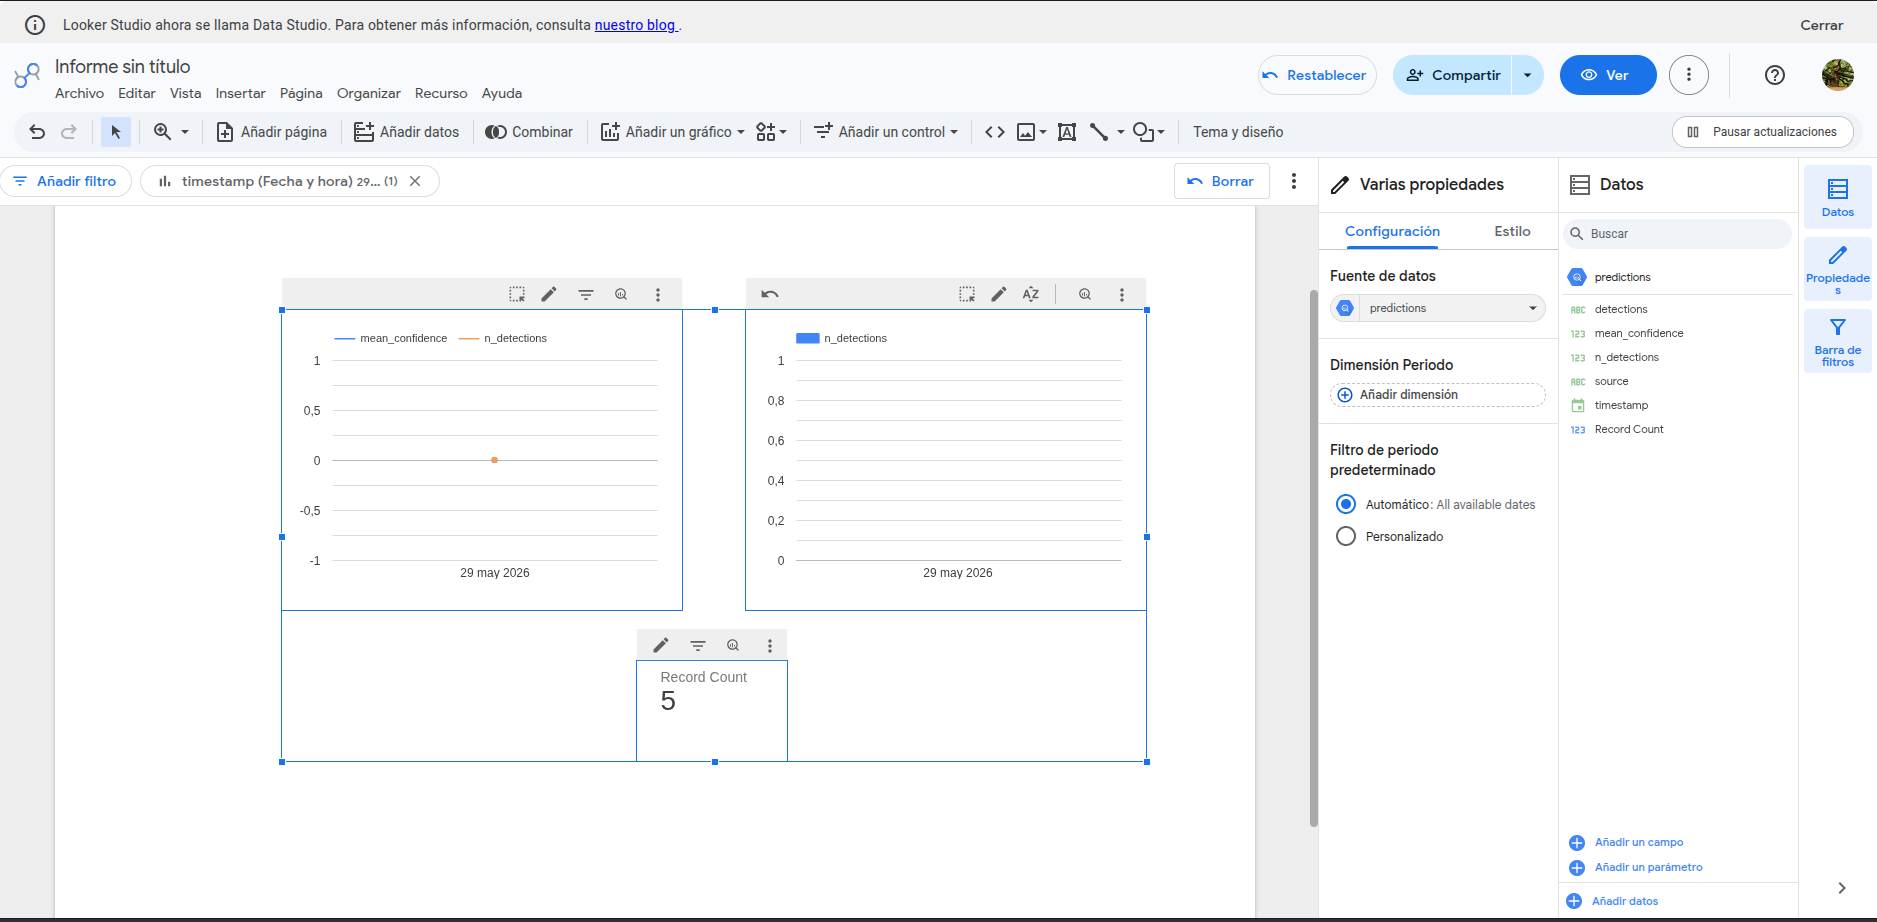

## 8. Infrastructure monitoring — Cloud Monitoring

Cloud Run integrates automatically with **Cloud Monitoring** — no
additional configuration required. Every request to the API generates
metrics that are available at

```
https://console.cloud.google.com/monitoring
```

The most relevant metrics for an ML API in production:

| Metric | What it measures | Why it matters |
|---|---|---|
| `request_count` | Total requests per minute | Detects traffic anomalies |
| `request_latencies` | Response time distribution (p50, p95, p99) | Detects performance degradation |
| `container/instance_count` | Number of active instances | Detects unexpected scaling |
| `container/cpu/utilization` | CPU usage per instance | Detects compute bottlenecks |
| `container/memory/utilization` | Memory usage per instance | Detects memory leaks |

### Infrastructure vs model monitoring

These two monitoring layers answer different questions:

| | Cloud Monitoring | BigQuery + Looker Studio |
|---|---|---|
| Answers | Is the server healthy? | Is the model healthy? |
| Alerts on | High latency, error rate, crashes | Confidence drift, detection rate changes |
| Reacts to | Infrastructure failures | Data distribution shifts |

A production ML system needs both. A server that is running perfectly
can still serve degraded predictions if the model has drifted — and
Cloud Monitoring alone would never detect that.

### Setting a budget alert

To avoid unexpected GCP costs, set a budget alert at
https://console.cloud.google.com/billing/budgets:

1. Click **Create budget**
2. Set amount to $10/month
3. Add alert thresholds at 50%, 90%, and 100%
4. Enable email notifications

Cloud Run's free tier covers 2 million requests/month and 360,000
vCPU-seconds/month — more than sufficient for this tutorial.

## 9. Summary

### What this notebook demonstrated

This notebook built a complete MLOps pipeline around a YOLO model
fine-tuned on solar imagery — from a local FastAPI server to a
containerized, cloud-deployed, monitored production system.

The five components and what each one contributes:

| Component | Tool | Industry skill demonstrated |
|---|---|---|
| API | FastAPI | REST API design, request/response schemas, async endpoints |
| Containerization | Docker | Reproducible environments, layer caching, build optimization |
| Cloud deployment | GCP Cloud Run | Serverless deployment, IAM, Service Accounts, least privilege |
| Model monitoring | BigQuery + Looker Studio | Drift detection, analytical queries, dashboard design |
| Infrastructure monitoring | Cloud Monitoring | Latency, error rate, scaling metrics |

### The astronomy argument

The model being monitored here detects solar events — Active Regions,
Filaments, Coronal Holes, and Sigmoids. The pipeline is identical to
what a solar observatory would deploy for near real-time event detection.
Every skill demonstrated in this notebook — API design, containerization,
cloud deployment, and monitoring — maps directly to what industry ML
engineering roles require, regardless of the domain.

### What would make this production-ready

1. **Authentication:** remove `--allow-unauthenticated` and implement
   OAuth2 token validation on every request.
2. **Model quality:** retrain on the full LSDO dataset (2012-2014) with
   a temporally stratified split — see the LSDO notebook for resource
   estimates.
3. **Drift alerting:** implement a Cloud Scheduler job that runs the
   drift detection query daily and sends an email alert when
   `mean_confidence` drops more than 20% below baseline.
4. **CI/CD pipeline:** automate the rebuild and redeploy steps using
   Cloud Build — every push to the main branch triggers a new deployment.
5. **Versioned images:** replace `latest` with semantic versioning
   or Git commit hashes to ensure reproducible deployments.

### What comes next

The final notebook in this series explains the internal architecture
of YOLO — backbone, neck, head, anchor boxes, and the loss function —
using Manim animations. Having seen the full pipeline from zero-shot
inference to production deployment, the architectural decisions behind
YOLO now have concrete context.